Supervised Learning using Salary Dataset
Introduction to Machine Learning & Workflow


What is Machine Learning?
Machine Learning is a branch of Artificial Intelligence that enables systems to learn patterns from data and make predictions without being explicitly programmed.

Instead of writing fixed rules, we train models using historical data.

Example
If we provide employee data such as:

Years of Experience
Education
Job Role
and corresponding Salary,

the model learns patterns and predicts salary for new employees.



Types of Machine Learning

1. Supervised Learning
Uses labeled data.

Input Features (X) → Output Target (Y)

Examples:

Salary Prediction
House Price Prediction
Spam Detection
Disease Prediction

2. Unsupervised Learning
Uses unlabeled data.

Examples:

Customer Segmentation
Pattern Detection
Clustering

3. Reinforcement Learning
Learns through rewards and penalties.

Examples:

Robotics
Self Driving Cars
Game AI


Our Focus: Supervised Learning

We will learn:

Regression using Linear Regression
Classification using Logistic Regression
Classification using Decision Tree
Using one common dataset.

Salary Dataset
Kaggle Dataset Link:

https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 1: Upload kaggle.json
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os
import shutil

# Create Kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')

# Set permission
os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d abhishek14398/salary-dataset-simple-linear-regression

Dataset URL: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
License(s): CC0-1.0
100% 457/457 [00:00<00:00, 1.32MB/s]



In [ ]:
import zipfile
import os
import pandas as pd

# Extract ZIP
with zipfile.ZipFile('salary-dataset-simple-linear-regression.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# 🔍 Find CSV file automatically
csv_path = None
for root, dirs, files in os.walk('data'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)

print("CSV found at:", csv_path)

# 📂 Load dataset
df = pd.read_csv(csv_path)

# 👀 Preview
print(df.head())
print(df.info())

CSV found at: data/Salary_dataset.csv
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


Step 3: View Dataset

In [ ]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


Step 4: Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [ ]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


Step 5: Check Missing Values

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


Step 6: Check Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(0)

Step 7: Remove Duplicate Rows

In [ ]:
df.drop_duplicates(inplace=True)

# Step 8: Column Names

In [ ]:
df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

# Step 9: Visualize Dataset

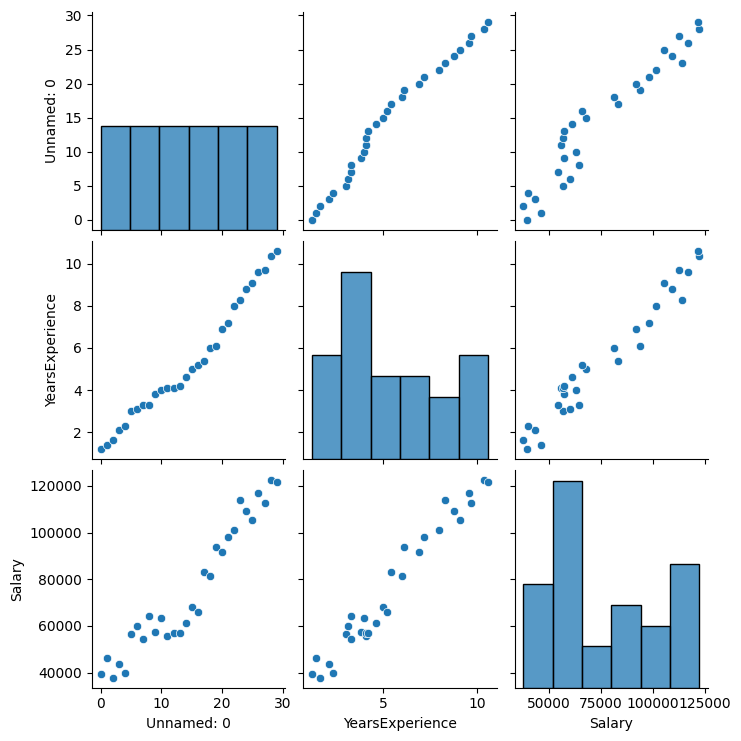

In [ ]:
sns.pairplot(df)
plt.show()

Machine Learning Workflow

Define Problem Statement
Collect Data
Load Data
Clean Data
Exploratory Data Analysis
Preprocessing
Feature Engineering
Train Test Split
Model Training
Prediction
Evaluation
Deployment

Feature Engineering Example

In [ ]:
df['Experience_Squared'] = df['YearsExperience'] ** 2
df.head()

,Unnamed: 0,YearsExperience,Salary,Experience_Squared
0,0,1.2,39344.0,1.44
1,1,1.4,46206.0,1.96
2,2,1.6,37732.0,2.56
3,3,2.1,43526.0,4.41
4,4,2.3,39892.0,5.29


Why Feature Engineering?
Sometimes original features are not enough.

Creating new meaningful columns can improve model performance.

Target Variable

For this dataset:

Input Feature (X): YearsExperience
Target (Y): Salary

Next Section
We will now build our first supervised model:

Linear Regression

Linear Regression
Predicting Salary using Years of Experience

What is Linear Regression?
Linear Regression is a supervised learning algorithm used when the target variable is continuous.

It finds the best fit straight line between input feature and target variable.

Example:

Years of Experience → Salary

Linear Equation

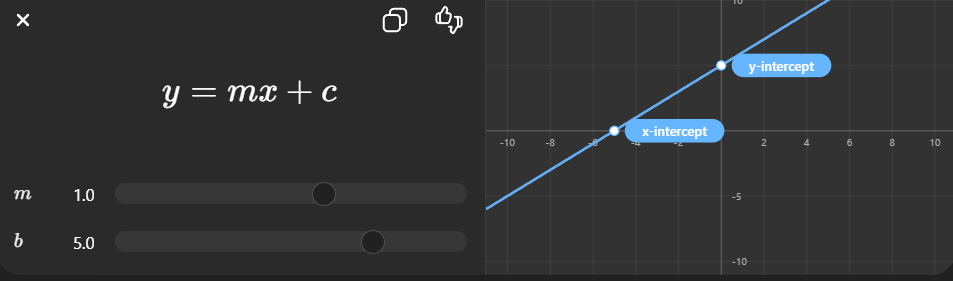

Where:

y = Predicted Salary
x = Years of Experience
m = Slope
c = Intercept


Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Step 2: Load Dataset

In [ ]:
import zipfile
import os
import pandas as pd

# Extract ZIP
with zipfile.ZipFile('salary-dataset-simple-linear-regression.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# 🔍 Find CSV file automatically
csv_path = None
for root, dirs, files in os.walk('data'):
    for file in files:
        if file.endswith('.csv'):
            csv_path = os.path.join(root, file)

print("CSV found at:", csv_path)

# 📂 Load dataset
df = pd.read_csv(csv_path)

# 👀 Preview
print(df.head())
print(df.info())

CSV found at: data/Salary_dataset.csv
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


Step 3: Data Cleaning

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
df.drop_duplicates(inplace=False)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [ ]:
df.shape

(30, 3)

Step 4: Exploratory Data Analysis

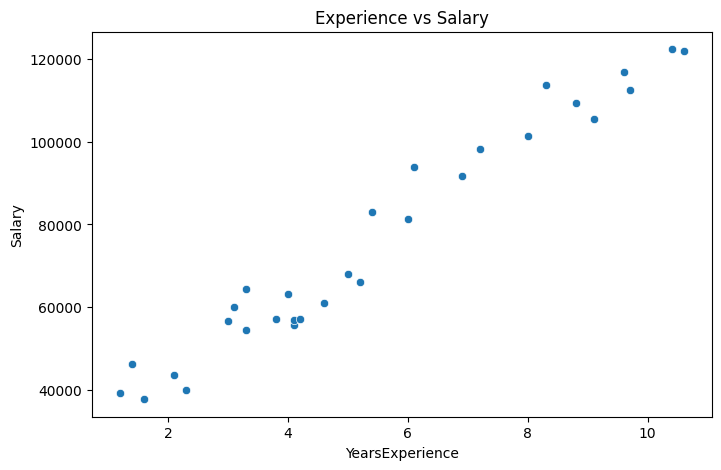

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Experience vs Salary")
plt.show()


Strong positive relationship is expected between experience and salary.



Step 5: Feature Engineering

In [ ]:
df['Experience_Squared'] = df['YearsExperience'] ** 2
df.head()

,Unnamed: 0,YearsExperience,Salary,Experience_Squared
0,0,1.2,39344.0,1.44
1,1,1.4,46206.0,1.96
2,2,1.6,37732.0,2.56
3,3,2.1,43526.0,4.41
4,4,2.3,39892.0,5.29


We created one extra feature to capture possible non-linear growth.

Step 6: Define Features and Target

In [ ]:
X = df[['YearsExperience', 'Experience_Squared']]
y = df['Salary']

Step 7: Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

Step 8: Feature Scaling

StandardScaler() → Creates a scaler object that standardizes the data.

fit_transform(X_train) → fit: Learns the mean and standard deviation from the training data.

transform: Uses those values to scale the training data.

transform(X_test) → Scales the test data using the same mean and standard deviation learned from the training data.

We use only transform() on the test data because we should not learn anything from the test set.

Why do we use StandardScaler?

It brings all features to a similar scale, so machine learning models can learn better and make more accurate predictions.

One-line definition: StandardScaler converts all numerical features to a similar scale (mean = 0 and standard deviation = 1), which helps the model train more effectively.

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 9: Train Model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Step 10: Model Coefficients
Intercept: Starting value of the model.

Coefficients: Importance (weight) of each input feature in making predictions.

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 79932.79166666667
Coefficients: [28755.60211142 -1712.02696398]


Step 11: Prediction
model.predict(X_test) predicts the target values for the test dataset, and y_pred stores those predictions.

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([63261.87731122, 61341.3651367 , 36023.39018183, 64220.68566489,
       56523.19447509, 90675.46634078])

Step 12: Evaluation Metrics

For Regression

Use

MSE

RMSE

R²

For Classification

Accuracy

Precision

Recall

F1

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 3180.211010881085
MSE : 17450023.36360711
RMSE: 4177.322511323146
R2 Score: 0.9302148364222369


Metric Meaning
MAE → Average error
RMSE → Penalizes larger errors
R² Score → How well model explains data

Step 13: Actual vs Predicted

In [ ]:
result = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

result

,Actual Salary,Predicted Salary
0,63219.0,63261.877311
1,57190.0,61341.365137
2,39344.0,36023.390182
3,55795.0,64220.685665
4,54446.0,56523.194475
5,91739.0,90675.466341


Step 14: Visualization

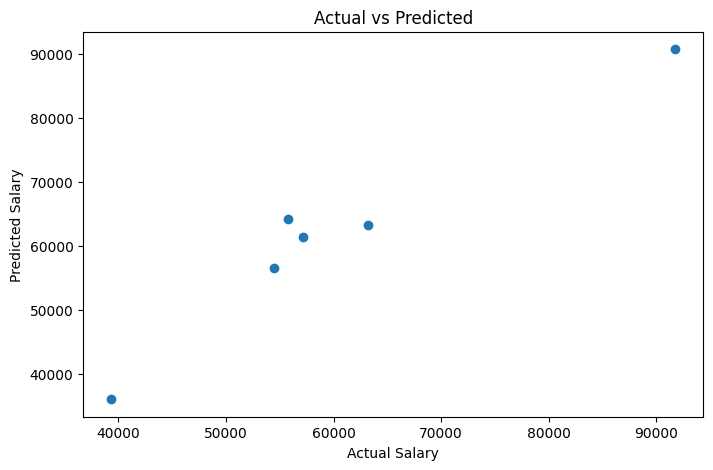

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

Step 15: Predict New Employee Salary

In [ ]:
new_data = pd.DataFrame({
    'YearsExperience':[2.4],
    'Experience_Squared':[5.76]
})

new_scaled = scaler.transform(new_data)

prediction = model.predict(new_scaled)
print("Predicted Salary:", prediction[0])

Predicted Salary: 47789.68247316196


Conclusion
Linear Regression learns relationship between experience and salary and predicts future salary values.

Sum Example https://allen.in/jee/maths/linear-regression

In [ ]:
# 2. Create Dataset (self-contained)
data = pd.DataFrame({
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
               63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
               91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
})

Multiple Linear Regression

Multiple Linear Regression: More than one independent variable.

Epoch	Train MSE	Test MSE
1	11849425446564939824103424.00		11388075747545116460449792.00
2	15925177495398733236404224.00		14952382855479162470137856.00
3	3406840578550295418634240.00		3177082669421484327305216.00
4	5233842758675684401348608.00		5111067950246870623715328.00
5	3233536438583469031817216.00		3159885077877544416444416.00
6	9236174563198308118953984.00		8681382811823004725542912.00
7	7165951283096382823464960.00		6744211514531958191292416.00
8	5079713977566980118413312.00		4862680897494965454635008.00
9	6016808081650933861187584.00		5706340049763513298583552.00
10	4101234205309745298931712.00		3905519863936903704215552.00
11	3745287607155206186336256.00		3556671847906625412136960.00
12	3662278869968934670434304.00		3440231009583181460406272.00
13	4512105701765311639846912.00		4202932663623271890026496.00
14	1627590951249342837555200.00		1481703732335110816530432.00
15	1839662438066127605071872.00		1674503658865232470605824.00
16	4042878248929575282147328.00		39058680021930002

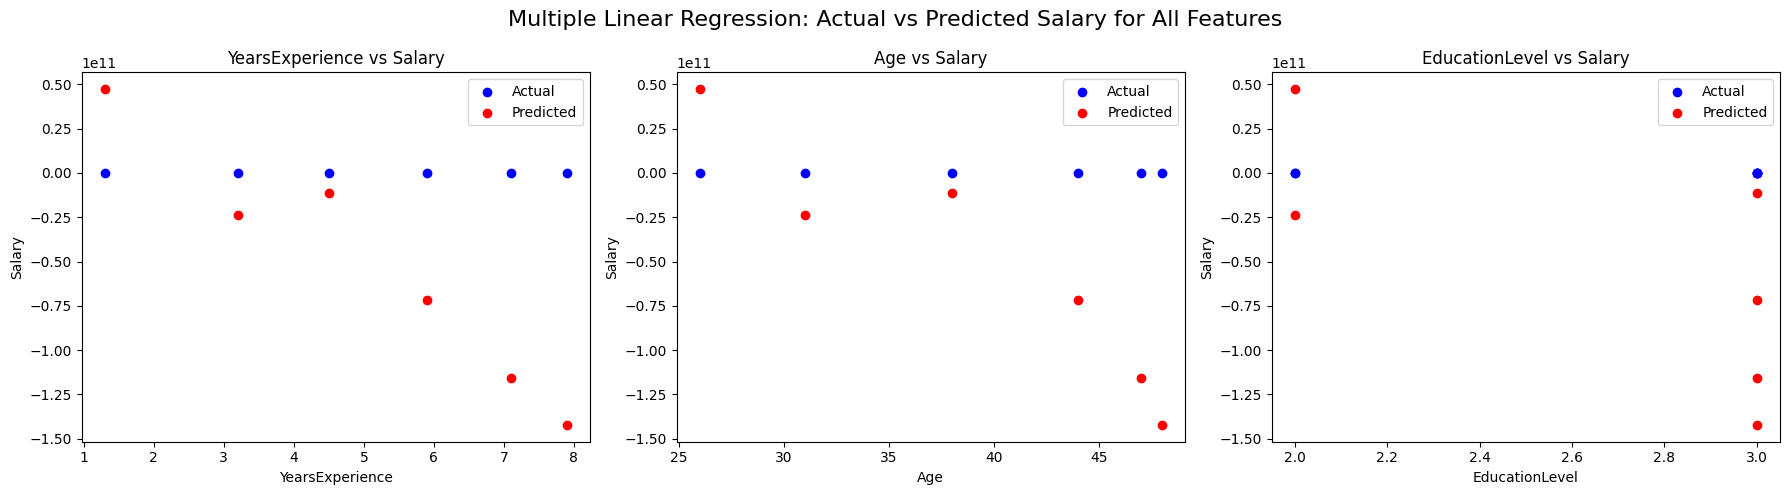

In [ ]:
# ==============================
# Multiple Linear Regression with Epochs: Salary Prediction
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 2. Create Self-Contained Dataset
# Features: YearsExperience, Age, EducationLevel
# Target: Salary
data = pd.DataFrame({
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Age': [25, 26, 24, 28, 27, 30, 32, 31, 33, 34,
            35, 36, 36, 37, 38, 40, 41, 42, 44, 45,
            46, 47, 48, 49, 50, 51, 52, 53, 54, 55],
    'EducationLevel': [1, 2, 1, 2, 2, 3, 3, 2, 2, 3,
                       3, 3, 2, 2, 3, 3, 3, 3, 3, 3,
                       3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
               63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
               91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
})

# 3. Define features (X) and target (y)
X = data[['YearsExperience', 'Age', 'EducationLevel']].values
y = data['Salary'].values

# 4. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# 5. Initialize SGDRegressor for Multiple Linear Regression
sgd_model = SGDRegressor(max_iter=1, tol=None, eta0=0.01, random_state=12)

# 6. Train with explicit epochs
epochs = 100
print("Epoch\tTrain MSE\tTest MSE")
for epoch in range(1, epochs + 1):
    sgd_model.partial_fit(X_train, y_train)  # one pass over training data

    # Predictions
    y_train_pred = sgd_model.predict(X_train)
    y_test_pred = sgd_model.predict(X_test)

    # Compute MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f"{epoch}\t{train_mse:.2f}\t\t{test_mse:.2f}")

# 7. Final model parameters
print("\nFinal Coefficients:", sgd_model.coef_)
print("Final Intercept:", sgd_model.intercept_)

# 8. Visualization: Actual vs Predicted for each feature
features = ['YearsExperience', 'Age', 'EducationLevel']
X_test_df = pd.DataFrame(X_test, columns=features)
y_test_pred = sgd_model.predict(X_test)

plt.figure(figsize=(18, 5))
for i, feature in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_test_df[feature], y_test, color='blue', label='Actual')
    plt.scatter(X_test_df[feature], y_test_pred, color='red', label='Predicted')
    plt.xlabel(feature)
    plt.ylabel("Salary")
    plt.title(f"{feature} vs Salary")
    plt.legend()

plt.suptitle("Multiple Linear Regression: Actual vs Predicted Salary for All Features", fontsize=16)
plt.tight_layout()
plt.show()